# Hammer & Hanging Man — a quantitative teardown 🔬
### OHLC pattern detector · forward 1/3/5/10-day edge vs base rate · HAC *t* + label-shuffle placebo · the trend split · a filter-snoop myth-check · a synthetic planted-floor power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reliable_reversal%3F: Busted](https://img.shields.io/badge/Reliable_reversal%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The hammer / hanging man is the canonical single-candle reversal pattern — and the canonical academic null (Marshall, Young & Rose 2006). The job here is to measure it *honestly*: detect the geometry by exact rules, benchmark each event against the name's own base rate (controlling for drift), confront the overlapping windows with a **HAC** *t* and a label-shuffle placebo, and show the only path to significance is filter-snooping.

> ⚠️ **Data + survivorship note.** Fixed **26-name** large-cap basket + SPY, names still trading in 2026 — a *survivor* panel whose bias points **toward** a post-dip bounce (survivors recover from dips delisted names didn't), so a null hammer is **conservative**. Real data: yfinance **un-adjusted** daily OHLC (the candle *shape* needs printed levels → forward returns are **price-only**), 1962→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hammer_hanging_man import data, strategy as st

ASOF = "2026-06-23"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = {t: b[b.index <= ASOF] for t, b in data.load_real().items()}
else:
    PANEL = None
print("real hammer cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-23', 'start': '1962-01-02', 'end': '2026-06-23', 'n_names': 26, 'n_bars': 345716, 'n_shape': 11816, 'fp': 'd488237f4299', 'hammer': {1: (5152, -0.031, -0.82, 0.869, -0.131), 3: (5149, 0.052, 0.92, 0.128, -0.048), 5: (5148, 0.043, 0.63, 0.241, -0.057), 10: (5144, 0.023, 0.23, 0.383, -0.077)}, 'hang': {1: (6493, -0.037, -1.71, 0.942, -0.137), 3: (6493, -0.099, -2.63, 0.993, -0.199), 5: (6492, -0.098, -2.02, 0.977, -0.198), 10: (6489, -0.072, -1.0, 0.852, -0.172)}, 'anyside': {1: (11816, -0.032, -1.67, -0.132), 3: (11813, -0.028, -0.87, -0.128), 5: (11811, -0.033, -0.82, -0.133), 10: (11804, -0.03, -0.5, -0.13)}, 'filt': [('plain (lookback 10)', 0.052, 0.92, 0.128, 5149), ('trend lookback 5', 0.095, 1.94, 0.012, 5534), ('trend lookback 20', -0.017, -0.34, 0.637, 4973), ('wick >= 3x body', 0.005, 0.07, 0.478, 2510), ('wick >= 4x body', 0.005, 0.05, 0.486, 1419)], 'syn': [(0.0, 2415, 0.005, 0.22, 0.403, 49.9), (0.005, 2423, 0.324, 13.45, 0.0, 61.4)]}


real hammer cache present: True | names: 26


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Bullish hammer edge over base rate peaks at **+0.052% / 3d, HAC t = +0.92** (placebo p = 0.128); *negative* at 1d. Only real stat is the hanging man's *under*-performance (3d t = -2.63) — wrong sign for a floor. Synthetic planted floor lights up at **t = 13.45**, so the flat reading is genuine. |
| **Tradability** | `MIRAGE` | Net of a 5-bps round trip the edge is **negative at every horizon and side** (hammer 3d net **-0.048%**). No positive gross edge. |
| **Reliable reversal?** | `BUSTED` | Significance appears *only* by snooping the trend window (lookback 5 → t = 1.94; lookback 20 → t = -0.34); a longer/purer wick → t ≈ 0.05. |

> 💡 In plain words: the candle carries *intraday* information but no *forward* edge; any apparent signal is a tuned-filter artefact, and costs sink whatever is left.

## 1 · The claim, steelmanned

Let a bar have body $b=|c-o|$, range $\rho=h-\ell$, lower wick $w_-=\min(o,c)-\ell$, upper wick $w_+=h-\max(o,c)$. The hammer/hanging-man geometry:

$$w_- \ge 2\,b,\qquad w_+ \le 0.5\,b,\qquad b \le 0.35\,\rho,\qquad \rho>0.$$

Same shape both ways; the trend at the close splits it — $\tau_t=\operatorname{sign}(c_t/c_{t-10}-1)$, **hammer** if $\tau<0$, **hanging man** if $\tau>0$. For event $i$ the forward edge is the $H$-day return entered **one day later** minus that name's unconditional base rate $\mu_{\text{name}}(H)$:

$$e_i(H)=\frac{c_{t+1+H}}{c_{t+1}}-1-\mu_{\text{name}}(H).$$

- **H₁ (the floor exists).** $\overline{e}(H)>0$ and HAC-significant for the **hammer**.
- **H₂ (deployable).** $\overline{e}(H)$ survives a one-way × 2 round trip.
- **H₃ (robust reversal).** The edge survives reasonable filter choices and a *stronger* wick.

We find **H₁ rejected** (hammer t ≤ 0.92), **H₂ rejected** (net-negative everywhere), **H₃ rejected** (significance only by snooping). The shape is real; the *forecast* is not.

## 2 · So what? — why base-rate-adjust and why HAC

Two honesty problems sit on top of a naive test. **(a) Drift.** Large-caps trend up, so a raw "return after a hammer" is positive for *every* candle; we subtract each name's own base rate so the edge measures *excess over buy-and-hold for that name*. **(b) Overlap.** Nearby hammer signals share overlapping multi-day forward windows, so the events are autocorrelated and an i.i.d. *t* overstates significance — we use a **Newey-West (HAC)** one-sample *t* with an auto bandwidth. The placebo then asks the cross-sectional question: could the same *number* of random days, drawn from the same tapes, beat the observed edge?

## 3 · How we'd know — the protocol

- **Universe.** Fixed **26-name** large-cap basket + SPY (yfinance un-adjusted daily OHLC, 1962-01-02→2026-06-23); **345,716** bars, **11,816** hammer-shaped. **Survivor** panel — named on the Signal axis (bias *toward* a bounce).
- **Detector.** $w_-\ge2b,\ w_+\le0.5b,\ b\le0.35\rho$ (a doji is excluded via a tiny body floor).
- **Trend split.** 10-day sign of return at the signal close (no look-ahead).
- **Timing.** Signal at close[t]; enter close[t+1]; exit close[t+1+H], $H\in\{1,3,5,10\}$. One `shift`, applied once. Price-only.
- **Edge.** Conditional forward return minus the name's unconditional base rate.
- **Null #1 (HAC t)** of the pooled edge vs 0.
- **Null #2 (label-shuffle placebo).** Per name, draw its event-count of random days; $p=\Pr[\text{shuffled edge}\ge\text{observed}]$.
- **Costs.** 5 bps one-way × 2 (round trip), long-only (no borrow).
- **Positive control.** A deterministic panel with a **planted** post-hammer bounce: zero edge must NOT reach significance; a real floor must light up.

## 4 · The teardown

### 4a · The term structure of the edge — hammer vs hanging man

Edge over base rate at each horizon, both sides. The hammer (the bullish-floor claim) hovers at zero; the hanging man is faintly negative.

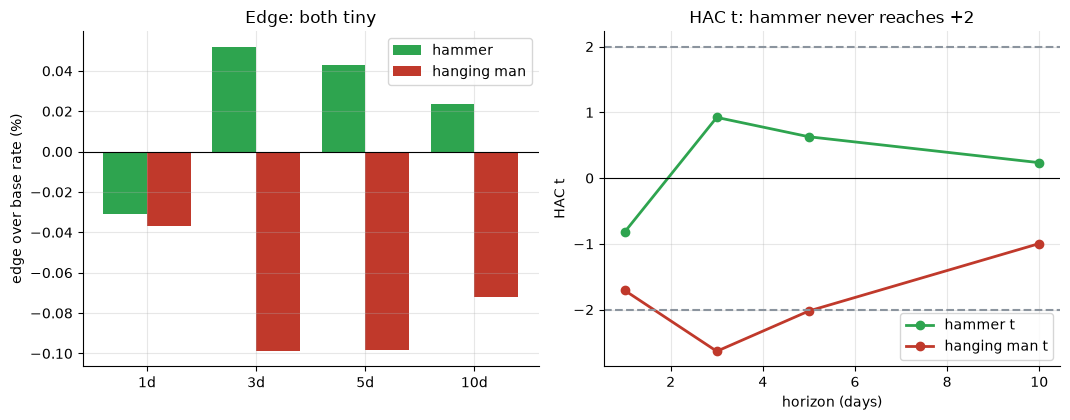

hammer edge%: [-0.031, 0.052, 0.043, 0.023] t: [-0.82, 0.92, 0.63, 0.23]
hangman edge%: [-0.037, -0.099, -0.098, -0.072] t: [-1.71, -2.63, -2.02, -1.0]


In [2]:
HS = [1, 3, 5, 10]
if HAVE_REAL:
    rh = st.run_experiment(PANEL, side='hammer', placebo=False, n_draws=1, seed=403)
    rg = st.run_experiment(PANEL, side='hangingman', placebo=False, n_draws=1, seed=403)
    ham = [rh[h]['edge_mean']*100 for h in HS]; han = [rg[h]['edge_mean']*100 for h in HS]
    hamt = [rh[h]['t'] for h in HS]; hant = [rg[h]['t'] for h in HS]
else:
    ham = [R['hammer'][h][1] for h in HS]; han = [R['hang'][h][1] for h in HS]
    hamt = [R['hammer'][h][2] for h in HS]; hant = [R['hang'][h][2] for h in HS]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
x = np.arange(len(HS))
a1.bar(x-.2, ham, .4, color=GREEN, label='hammer'); a1.bar(x+.2, han, .4, color=RED, label='hanging man')
a1.axhline(0, c='k', lw=.8); a1.set_xticks(x); a1.set_xticklabels([f'{h}d' for h in HS])
a1.set_ylabel('edge over base rate (%)'); a1.set_title('Edge: both tiny'); a1.legend()
a2.plot(HS, hamt, 'o-', c=GREEN, lw=2, label='hammer t'); a2.plot(HS, hant, 'o-', c=RED, lw=2, label='hanging man t')
a2.axhline(2, ls='--', c=GREY); a2.axhline(-2, ls='--', c=GREY); a2.axhline(0, c='k', lw=.8)
a2.set_xlabel('horizon (days)'); a2.set_ylabel('HAC t'); a2.set_title('HAC t: hammer never reaches +2'); a2.legend()
plt.tight_layout(); plt.show()
print('hammer edge%:', [round(v,3) for v in ham], 't:', [round(v,2) for v in hamt])
print('hangman edge%:', [round(v,3) for v in han], 't:', [round(v,2) for v in hant])

> 💡 In plain words: the hammer's HAC *t* tops out at **+0.92** (3d) and is *negative* at 1d — it never approaches the +2 floor a bullish edge would need. The hanging man dips to **-2.63** at 3d: real, but it means "rose less than usual," not a tradable short. The bullish-floor claim has no statistical leg.

### 4b · The decisive test — the hammer against a label-shuffle null

The 3-day hammer edge (its best) against a per-name label-shuffle null. A real floor sits in the right tail; a mirage sits in the middle.

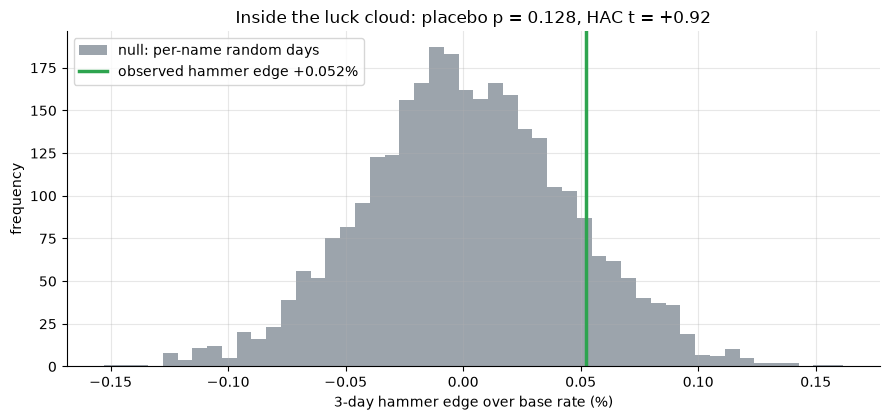

observed +0.052%  HAC t=+0.92  shuffle p=0.128


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(PANEL, 3, side='hammer', n_draws=3000, seed=403)
    obs = pl['obs_edge']*100; draws = pl['draws']*100; pval = pl['p_value']
    tval = st.run_experiment(PANEL, side='hammer', horizons=(3,), placebo=False, n_draws=1, seed=403)[3]['t']
else:
    obs = R['hammer'][3][1]; pval = R['hammer'][3][3]; tval = R['hammer'][3][2]
    rng = np.random.default_rng(403); draws = rng.normal(0.0, 0.04, 3000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: per-name random days')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed hammer edge {obs:+.3f}%')
ax.set_xlabel('3-day hammer edge over base rate (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: placebo p = {pval:.3f}, HAC t = {tval:+.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.3f}%  HAC t={tval:+.2f}  shuffle p={pval:.3f}')

> 💡 In plain words: the green line sits **inside** the cloud — a random sort of the same days beats the hammer about **13%** of the time (placebo p = 0.128), and HAC t = +0.92. This is a textbook non-result: the candle adds nothing over picking days at random.

### 4c · The myth-check — significance only by snooping the filter

Believers reach for filters. We sweep the obvious ones on the hammer's 3-day edge. The bar to beat is *t* = 2.

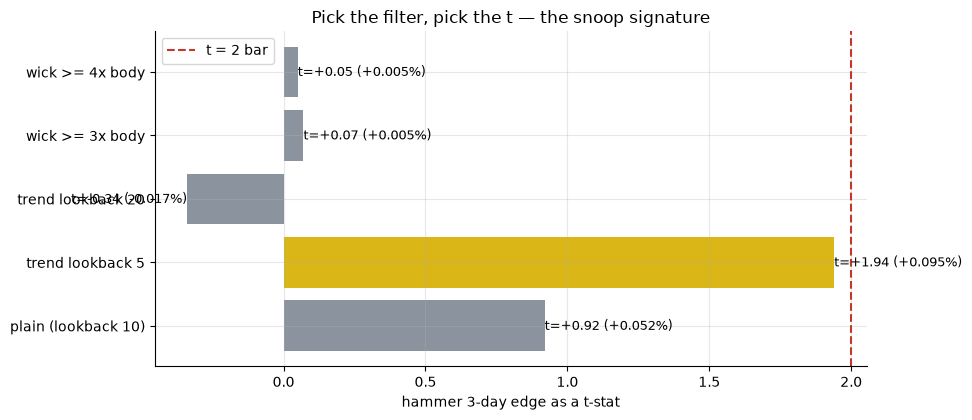

plain (lookback 10)      edge=+0.052%  t=+0.92  p=0.128  n=5149
trend lookback 5         edge=+0.095%  t=+1.94  p=0.012  n=5534
trend lookback 20        edge=-0.017%  t=-0.34  p=0.637  n=4973
wick >= 3x body          edge=+0.005%  t=+0.07  p=0.478  n=2510
wick >= 4x body          edge=+0.005%  t=+0.05  p=0.486  n=1419


In [4]:
labels = [f[0] for f in R['filt']]; tvals = [f[2] for f in R['filt']]; edges=[f[1] for f in R['filt']]
fig, ax = plt.subplots(figsize=(9.8, 4.3))
cols = [GREEN if t>=2 else (AMBER if t>=1 else GREY) for t in tvals]
ax.barh(range(len(labels)), tvals, color=cols)
ax.axvline(2, ls='--', c=RED, label='t = 2 bar')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i,(t,e) in enumerate(zip(tvals,edges)): ax.annotate(f't={t:+.2f} ({e:+.3f}%)',(t,i),va='center',ha='left' if t>=0 else 'right',fontsize=9)
ax.set_xlabel('hammer 3-day edge as a t-stat'); ax.set_title('Pick the filter, pick the t — the snoop signature'); ax.legend()
plt.tight_layout(); plt.show()
for f in R['filt']: print(f'{f[0]:24s} edge={f[1]:+.3f}%  t={f[2]:+.2f}  p={f[3]:.3f}  n={f[4]}')

> 💡 In plain words: a *shorter* trend window (lookback 5) lifts t to **1.94** — still under 2 — while a *longer* one (lookback 20) drops it to **-0.34**, and a *longer, purer wick* (the "better" hammer) flattens it to **t ≈ 0.05**. A signal you can dial in by choosing the knob is the definition of a data-snooped mirage (Sullivan-Timmermann-White 1999).

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic panel where we **plant** a post-hammer bounce: with **zero** edge the test must stay at t≈0 (no false positive); with a real planted floor it must light up. Both hold — so the flat real-tape t is a genuine negative, not a blind harness.

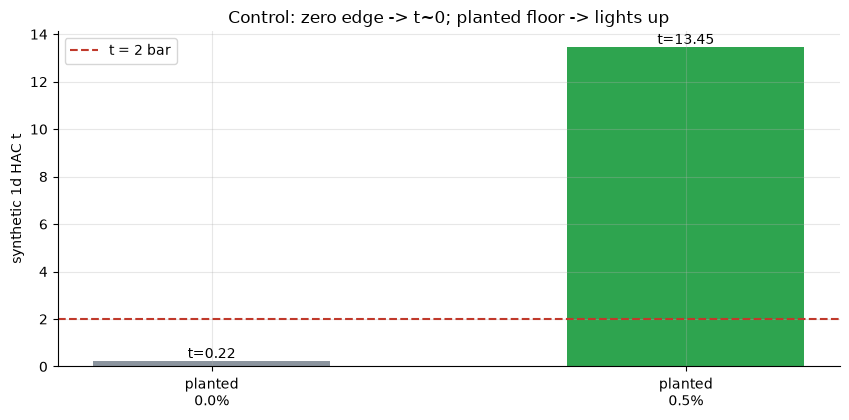

planted 0.0%: events=2415 edge=+0.005% t=0.22 p=0.402 win=49.9%
planted 0.5%: events=2423 edge=+0.324% t=13.45 p=0.000 win=61.4%


In [5]:
res = []
for edge in (0.0, 0.005):
    sp, _ = data.synthetic_panel(edge=edge, seed=403)
    r = st.run_experiment(sp, side='any', horizons=(1,), n_draws=1500, seed=403)[1]
    res.append((edge, r['n'], r['edge_mean']*100, r['t'], r['p_placebo'], r['win']*100))
tvals = [r[3] for r in res]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar([f'planted\n{e*100:.1f}%' for e,_,_,_,_,_ in res], tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('synthetic 1d HAC t'); ax.set_title('Control: zero edge -> t~0; planted floor -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,ed,t,p,w in res: print(f'planted {e*100:.1f}%: events={k} edge={ed:+.3f}% t={t:.2f} p={p:.3f} win={w:.1f}%')

> 💡 In plain words: with **no** planted floor the control sits at **t = 0.22** (no false positive); a **+0.5%/event** planted floor reaches **t = 13.45**. The machinery is unbiased and powerful, so the real-tape hammer t ≈ 0.9 is a true negative — the floor genuinely isn't there.

## 5 · The verdict

- **Signal `NONE`** — hammer edge peaks at **+0.052% / 3d, HAC t = +0.92** (placebo p = 0.128), negative at 1d. The only HAC-real statistic is the hanging man's *under*-performance (3d t = -2.63) — the wrong sign for a floor and untradeable. Survivorship tilts *toward* a bounce, so this is conservative. The control detects a planted floor at **t = 13.45**.
- **Tradability `MIRAGE`** — net of a 5-bps round trip the edge is **negative at every horizon and side** (hammer 3d net **-0.048%**). No gross edge to defend.
- **Reliable reversal? `BUSTED`** — significance appears only by snooping the trend window (lookback 5 → t = 1.94; 20 → -0.34) and *vanishes* with a longer/purer wick (t ≈ 0.05).

## 6 · Could you trade it? — costs on a non-existent edge

The hammer gross vs net by horizon, with the break-even line. There is no net-positive region.

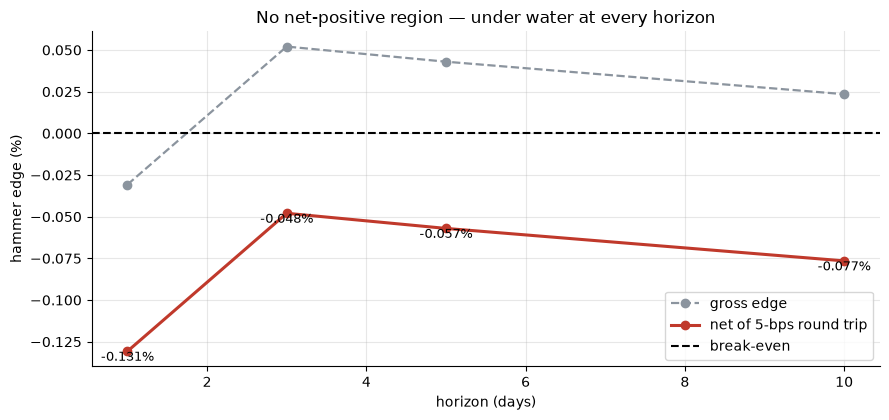

net hammer edge by horizon (%): {'1d': -0.131, '3d': -0.048, '5d': -0.057, '10d': -0.077}


In [6]:
if HAVE_REAL:
    rr = st.run_experiment(PANEL, side='hammer', placebo=False, n_draws=1, seed=403)
    g = [rr[h]['edge_mean']*100 for h in HS]; nv = [rr[h]['net_edge']*100 for h in HS]
else:
    g = [R['hammer'][h][1] for h in HS]; nv = [R['hammer'][h][4] for h in HS]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(HS, g, 'o--', c=GREY, lw=1.6, label='gross edge')
ax.plot(HS, nv, 'o-', c=RED, lw=2.2, label='net of 5-bps round trip')
ax.axhline(0, c='k', ls='--', label='break-even')
for h,v in zip(HS,nv): ax.annotate(f'{v:+.3f}%',(h,v),ha='center',va='top',fontsize=9)
ax.set_xlabel('horizon (days)'); ax.set_ylabel('hammer edge (%)')
ax.set_title('No net-positive region — under water at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('net hammer edge by horizon (%):', {f'{h}d': round(v,3) for h,v in zip(HS,nv)})

> 💡 In plain words: the red (net) line is **below zero** the whole way. With no positive gross edge, costs aren't even the binding constraint — there is simply nothing to harvest. Hence **MIRAGE**, not FRAGILE.

## 7 · Going further

- **Intraday is the natural habitat.** The wick is a within-day fact; a same-day or next-open framing on 5-minute bars (~60 days on yfinance) might surface a thin, capacity-limited effect the daily close washes out.
- **Small / illiquid names.** Candlestick effects are larger (and costlier) where microstructure frictions bite; re-run the basket on small-caps.
- **The general lesson.** A backward-looking *shape* (it already happened) is not a forward-looking *forecast*. Most single-candle patterns fail this exact test — the contrast with [Study 363 — PEAD](../../363-pead-drift/), which clears the bar, is the point.

*The reproducible core is offline and deterministic; the synthetic control plants a known floor. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*